# Toy Statistical Inversion Example #2

Consider the following statistical inverse problem taken from [1].
$$
    todo
$$

### References

<font size="2">
[1] Nathan E Glatt-Holtz, Andrew J Holbrook, Justin A Krometis, Cecilia F Mondaini
    Parallel MCMC algorithms: theoretical foundations, algorithm design, case studies 
    Transactions of Mathematics and Its Applications, Volume 8, Issue 2, December 2024,
<font>

In [2]:
#Packages to Import

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})



In [4]:
#Numerical Set up for AD Toy Model
#AD Toy Model

def MkAD_A_Mat(ModDim, curApar):
    """
    Generates an antisymmetric matric with the given Model Parameters
    """
    A = np.zeros([ModDim,ModDim])
    A[np.triu_indices(ModDim, k=1)] = curApar 
    #triu_indices returns the indices of all the above diagonal indicies
    return A - A.T

def getThA(ModDim, Apar, g, kappa):
    """
    Solves (A + kI) th = g  for theta given the specified model parameters determining A
    """
    A_p_kI = MkAD_A_Mat(ModDim, Apar)+ kappa*np.identity(ModDim)
    return np.linalg.solve(A_p_kI,g)

def mkDiagCov(vrs):
    return np.diag(vrs)


#Code to generate a random orthogonal matrix (uniform from O(n)) using the QR factorization of a Guassian matrix.
def rndm_orth_matrix(n):

    #Generate a random n x n matrix with i.i.d. normal entries
    A = np.random.randn(n, n)
    
    #Perform the QR factorization
    Q, R = np.linalg.qr(A)    
    
    return Q
    

In [19]:
#Example 1: From the Parallel MCMC paper

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 4
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0,g1, g2, g3)^T

g0 = .1
g1 = 0
g2 = 5
g3 = 2
g = np.transpose(np.array([g0,g1,g2,g3]))

# Coefficent of the `regularization/diffusion term'
kap = .05

#Specification `observed data' y0, y1
y0 = 4.601
y1 = 18.021

y = [y0,y1]

yData = np.array([y0,y1,0,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(0))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


Poty = lambda a : (2*sig**2)**(-1)*(norm(y - getThA(ModDm, a, g, kap)[0:2]))**2
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]
Cov = mkDiagCov(CovDiag)

In [4]:
#Specifying File Location to Save Data 

FileNmBase= "Data/Advection_Diffusion_Toy/"

paraStr = "gvec_" + str(g) + "_kap_" + str(kap) + "_y_" + str(y)+ "_sig_" + str(sig) + "_covdiag_" + str(CovDiag)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"

In [35]:
#Generate Data Using MpCN

#NumRuns =  1000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  100 #of total runs
NumSamps = 1000 #samples per run



rho = .93
pSmp = 100

print("  ")
print("MTMpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = locMpCNMTM(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1,True)
        q0 = cursamps[NumSamps+1]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))
        

  
MTMpCN Run
Total samples generated: 100000
rho Value: 0.93
p Value: 100
  


  0%|          | 0/100 [00:00<?, ?it/s]

Rejection rate:
0.4195804195804196
Rejection rate:
0.4145854145854146
Rejection rate:
0.41858141858141856
Rejection rate:
0.43356643356643354
Rejection rate:
0.41858141858141856
Rejection rate:
0.43956043956043955
Rejection rate:
0.4095904095904096
Rejection rate:
0.4485514485514486
Rejection rate:
0.44755244755244755
Rejection rate:
0.47152847152847155
Rejection rate:
0.5024975024975025
Rejection rate:
0.4155844155844156
Rejection rate:
0.44955044955044954
Rejection rate:
0.39760239760239763
Rejection rate:
0.4875124875124875
Rejection rate:
0.4645354645354645
Rejection rate:
0.4405594405594406
Rejection rate:
0.44555444555444557
Rejection rate:
0.44255744255744256
Rejection rate:
0.43156843156843155
Rejection rate:
0.42857142857142855
Rejection rate:
0.3806193806193806
Rejection rate:
0.42157842157842157
Rejection rate:
0.43456543456543456
Rejection rate:
0.4095904095904096
Rejection rate:
0.4175824175824176
Rejection rate:
0.4015984015984016
Rejection rate:
0.43756243756243757
Rejec

Number of MpCN Samples Now Available: 130259


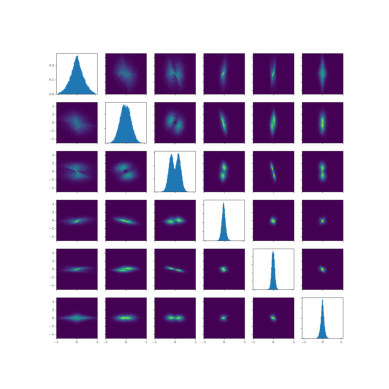

In [36]:
#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [29]:
#Example 2: Modification of Example 1 From the Parallel MCMC paper by Randomly Rotating the prior!

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 4
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0,g1, g2, g3)^T

g0 = .1
g1 = 0
g2 = 5
g3 = 2
g = np.transpose(np.array([g0,g1,g2,g3]))

# Coefficent of the `regularization/diffusion term'
kap = .05

#Specification `observed data' y0, y1
y0 = 4.601
y1 = 18.021

y = [y0,y1]

yData = np.array([y0,y1,0,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(0))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


Poty = lambda a : (2*sig**2)**(-1)*(norm(y - getThA(ModDm, a, g, kap)[0:2]))**2
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]

Q = rndm_orth_matrix(NumParms)
Cov = Q.T@ mkDiagCov(CovDiag)@ Q
print(Cov)

[[ 3.34752337  0.89756106 -1.3432909   1.22015807 -0.45513924 -0.40545139]
 [ 0.89756106  0.82993095 -0.37699072  0.28414354 -0.29307603  0.10159826]
 [-1.3432909  -0.37699072  1.44085559 -0.34722839  0.14341752  0.28611603]
 [ 1.22015807  0.28414354 -0.34722839  1.44768511 -0.10634107 -0.800496  ]
 [-0.45513924 -0.29307603  0.14341752 -0.10634107  0.73054669 -0.09082998]
 [-0.40545139  0.10159826  0.28611603 -0.800496   -0.09082998  1.34589619]]


  
MpCN Run
Total samples generated: 100000
rho Value: 0.6
p Value: 100
  


  0%|          | 0/100 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 99999


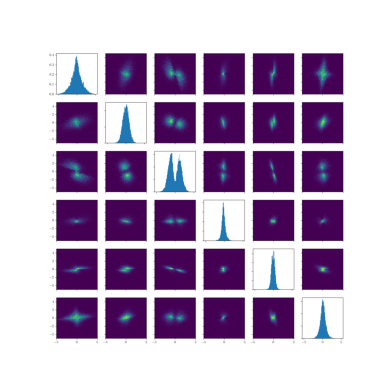

In [30]:
#Specifying File Location to Save Data 

FileNmBase= "Data/Advection_Diffusion_Toy/"

paraStr = "gvec_" + str(g) + "_kap_" + str(kap) + "_y_" + str(y)+ "_sig_" + str(sig) + "_CovSig_" + str(Cov[0,0])
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  5000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  100 #of total runs
NumSamps = 1000 #samples per run



rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [35]:
#Example 3:  Reduced Dimensional for larger scale studies

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 3 #Size of the matrix
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0, g1, g2)^T

g0 = 1
g1 = 1
g2 = -1

g = np.transpose(np.array([g0,g1,g2]))

# Coefficent of the `regularization/diffusion term'
kap = .1

#Specification `observed data' y0, y1
#Note, when A = 0, \th(A) =  kap^{-1} g.  So we specify y as y = \th(A) + \epsilon
eps0 = .3
eps1 = .1
y0 = kap**(-1)*g0 + eps0
y1 = kap**(-1)*g1 + eps1

y = [y0,y1]

yData = np.array([y0,y1,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(1))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


Poty = lambda a : (2*sig**2)**(-1)*(norm(y - getThA(ModDm, a, g, kap)[0:2]))**2
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]

Q = rndm_orth_matrix(NumParms)
Cov = Q.T@ mkDiagCov(CovDiag)@ Q
print(Cov)

#Cov = np.array([[3.65372175, -1.55416548, 0.86796861],[-1.55416548, 1.90906562, -0.7149217 ],[ 0.86796861, -0.7149217, 2.16723004]])

[[ 1.03167391 -0.19156758 -0.17457255]
 [-0.19156758  4.76682812 -0.836309  ]
 [-0.17457255 -0.836309    1.93151537]]


In [38]:
import time

rho = .1
pSmp = 10000
NumSamps = 10 #samples per run

q0 = np.random.normal(0,1,NumParms)


start_time = time.perf_counter()

MpCN_Olde_Ver(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time OLDE mpCN Code: {elapsed_time:.4f} seconds")


start_time = time.perf_counter()

MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time new mpCN Code: {elapsed_time:.4f} seconds")

Elapsed time OLDE mpCN Code: 3.7729 seconds
Elapsed time new mpCN Code: 1.6265 seconds


  
MpCN Run
Total samples generated: 10000
rho Value: 0.1
p Value: 100
  


  0%|          | 0/10 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 20039


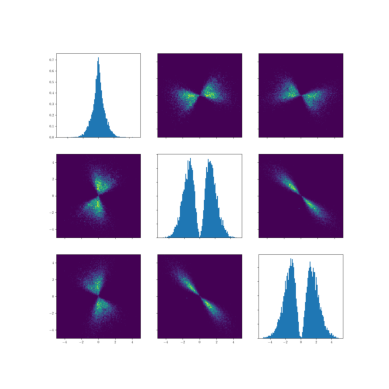

In [32]:
#Specifying File Location to Save Data 


FileNmBase= "Data/Advection_Diffusion_Toy/"

paraStr = "gvec_" + str(g) + "_kap_" + str(kap) + "_y_" + str(y)+ "_sig_" + str(sig) + "_Cov_" + str(Cov)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  5000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  10 #of total runs
NumSamps = 1000 #samples per run



rho = .1
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)
        q0 = cursamps[0]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [43]:
#Example 3:  Reduced Dimensional for larger scale studies

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 3 #Size of the matrix
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0, g1, g2)^T

g0 = 1
g1 = 1
g2 = -1

g = np.transpose(np.array([g0,g1,g2]))

# Coefficent of the `regularization/diffusion term'
kap = .1

#Specification `observed data' y0, y1
#Note, when A = 0, \th(A) =  kap^{-1} g.  So we specify y as y = \th(A) + \epsilon
eps0 = .3
eps1 = .1
y0 = kap**(-1)*g0 + eps0
y1 = kap**(-1)*g1 + eps1

y = [y0,y1]

yData = np.array([y0,y1,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(1))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)

idx = np.triu_indices(ModDm, 1)

def getThAN(aPar,b,kappa):
    A_pkI = np.zeros((ModDm, ModDm))
    i, j = idx
    A_pkI[i, j] = aPar
    A_pkI[j, i] = -aPar
    A_pkI[np.diag_indices(ModDm)] += kappa
    return np.linalg.solve(A_pkI, b)

Poty = lambda a : (2*sig**2)**(-1)*(norm(y - getThAN(a, g, kap)[0:2]))**2
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]

Q = rndm_orth_matrix(NumParms)
Cov = Q.T@ mkDiagCov(CovDiag)@ Q
print(Cov)

#Cov = np.array([[3.65372175, -1.55416548, 0.86796861],[-1.55416548, 1.90906562, -0.7149217 ],[ 0.86796861, -0.7149217, 2.16723004]])

[[ 1.82020235  0.57089039  0.07408832]
 [ 0.57089039  4.76623133 -0.7246498 ]
 [ 0.07408832 -0.7246498   1.14358372]]


In [44]:
rho = .1
pSmp = 10000
NumSamps = 10 #samples per run

q0 = np.random.normal(0,1,NumParms)


start_time = time.perf_counter()

MpCN_Olde_Ver(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time OLDE mpCN Code: {elapsed_time:.4f} seconds")


start_time = time.perf_counter()

MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time new mpCN Code: {elapsed_time:.4f} seconds")

Elapsed time OLDE mpCN Code: 2.9091 seconds
Elapsed time new mpCN Code: 0.7942 seconds


In [52]:
#Example 1: From the Parallel MCMC paper

#Speed ups

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 4
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0,g1, g2, g3)^T

g0 = .1
g1 = 0
g2 = 5
g3 = 2
g = np.transpose(np.array([g0,g1,g2,g3]))

# Coefficent of the `regularization/diffusion term'
kap = .05

#Specification `observed data' y0, y1
y0 = 4.601
y1 = 18.021

y = [y0,y1]

yData = np.array([y0,y1,0,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(0))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


PotOLDE = lambda a : (2*sig**2)**(-1)*(norm(y - getThA(ModDm, a, g, kap)[0:2]))**2

idx = np.triu_indices(ModDm, 1)

def getThAN(aPar,b,kappa):
    A_pkI = np.zeros((ModDm, ModDm))
    i, j = idx
    A_pkI[i, j] = aPar
    A_pkI[j, i] = -aPar
    A_pkI[np.diag_indices(ModDm)] += kappa
    return np.linalg.solve(A_pkI, b)

PotNew = lambda a : (2*sig**2)**(-1)*(norm(y - getThAN(a, g, kap)[0:2]))**2

CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]
Cov = mkDiagCov(CovDiag)

rho = .1
pSmp = 1000
NumSamps = 100 #samples per run

q0 = np.random.normal(0,1,NumParms)


start_time = time.perf_counter()

MpCN_Olde_Ver(q0,NumParms,Cov,rho,PotOLDE,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time OLDE mpCN Code: {elapsed_time:.4f} seconds")

start_time = time.perf_counter()

MpCN_parPot(q0,NumParms,Cov,rho,PotNew,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time parallel mpCN Code: {elapsed_time:.4f} seconds")


start_time = time.perf_counter()

MpCN(q0,NumParms,Cov,rho,PotNew,pSmp,NumSamps +1)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time new mpCN Code: {elapsed_time:.4f} seconds")

Elapsed time OLDE mpCN Code: 3.3749 seconds
Elapsed time parallel mpCN Code: 4.1654 seconds
Elapsed time new mpCN Code: 0.7012 seconds


In [66]:
#Example 4:  Higher Dimensions

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 6 #Size of the matrix
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}
#g0 = 1
#g1 = 1
#g = np.transpose(np.array([g0,g1,1,1,1,1]))

g = np.random.normal(0, 1, ModDm)

# Coefficent of the `regularization/diffusion term'
kap = .01

#Specification `observed data' y0, y1
#Note, when A = 0, \th(A) =  kap^{-1} g.  So we specify y as y = \th(A) + \epsilon
#eps0 = .3
#eps1 = .1
#y0 = kap**(-1)*g0 + eps0
#y1 = kap**(-1)*g1 + eps1

#y = [y0,y1]
#yData = np.array([y0,y1,0,0,0,0])


nyData = ModDm
#yData = np.random.normal(0, 1, ModDm)
#yData = getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)
yData = getThA(ModDm, np.zeros(NumParms), g, kap)

# `observation noise coefficent'

sig = .5

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(1))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


#Poty = lambda a : (2*sig**2)**(-1)*(np.sum(y - getThA(ModDm, a, g, kap)[0:1])**2)
Poty = lambda a : (2*sig**2)**(-1)*(np.sum(yData[0:nyData] - getThA(ModDm, a, g, kap)[0:nyData])**2)
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]

Q = rndm_orth_matrix(NumParms)
Cov = Q.T@ mkDiagCov(CovDiag)@ Q
#print(Cov)

expId = 7
probDataFile = FileNmBase + "Problem_Data_Ex_ID_4_" + str(expId) + ".txt"

with open(probDataFile, 'a') as file:
    file.write("model dim: " + str(ModDm) + "\n")
    file.write("gvec: " + str(g) + "\n")
    file.write("kap: " + str(kap) + "\n")
    file.write("y: " + str(yData) + "\n")
    file.write("sig: " + str(sig)+ "\n")
    file.write("Prior Cov: \n \t" + str(Cov))


In [76]:
#Specifying File Location to Save Data 


FileNmBase= "Data/Advection_Diffusion_Toy/"

paraStr = "Exp_Nm_4_" + str(expId)
histFileNm = FileNmBase + "_HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "_DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  500 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  100 #of total runs
NumSamps = 100000 #samples per run



rho = .9999
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        #cursamps = locMpCNMTM(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1,True)
        cursamps = MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)
        q0 = cursamps[NumSamps +1]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

  
MpCN Run
Total samples generated: 10000000
rho Value: 0.9999
p Value: 100
  


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

Number of MpCN Samples Now Available: 1000019


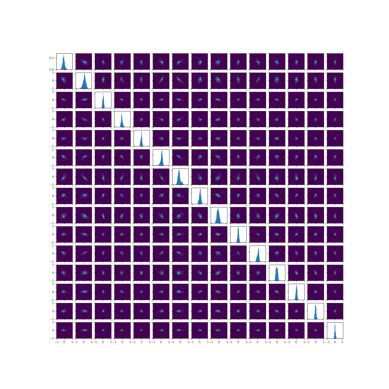

In [80]:
#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [78]:
g = np.ones(ModDm)
kap = .01

print(getThA(ModDm, np.zeros(NumParms), g, kap))

for k in range(1,15):
    print(getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))


[100. 100. 100. 100. 100. 100.]
[-2.42782403 -3.86312694  1.70691478 -1.92649127  1.96233509  5.12364767]
[ 0.88272921 -2.28978771 -0.93186563  1.15879482  0.7066722   0.56396673]
[-7.01159821  3.6355306   0.76354952 -1.88195173  5.33700119  0.10746336]
[-1.55260579 -0.02402605 -3.25813983  3.1735919   2.0596044  -0.12486578]
[-4.89112393  2.45160296  5.95556213 15.95839327 -5.29579261 -9.74735372]
[ 4.52148118  1.09817193 -0.67102601 -1.10376282 -4.89032849  1.54156498]
[-3.24946285  3.95179232  4.47701681  0.29599268  0.49451251 -5.23073096]
[  9.44560762 -10.98614021 113.43783512  36.05942384  95.85751609
  -7.57101346]
[-42.89235562  17.41312372   6.67064179  31.90646952  28.20105643
  -1.27477639]
[-1.16116657  0.16309536 -0.13933704  0.89782061  0.31568518 -0.05306876]
[ 1.14925586  1.71810914 -2.65887151 -1.25302848 -1.12076935  2.36281834]
[-0.28585742 -2.38237358 -3.51525601  9.70527402 -0.43439746 -1.92536439]
[-0.78304366 -1.0020105  -0.38574883  1.96559305 -0.08544018  0.34

In [41]:
ModDm = 4
NumParms = int(ModDm*(ModDm -1)/2)


g = np.ones(ModDm)
kap = .01

#print(getThA(ModDm, np.zeros(NumParms), g, kap))

aveLen = 5000

cent0 = np.zeros(NumParms)
print("Center: " + str(cent0))
th_0 = getThA(ModDm,cent0 , g, kap)
print("Example: " + str(norm(th_0  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
difflst0 = []
for k in range(1,aveLen):
    difflst0.append(norm(th_0  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

data0 = np.array(difflst0, dtype=float)
print("MEAN: " + str(data0.mean()))
print("VAR: " + str(data0.var(ddof=0)))
print("\n")

cent1 = np.ones(NumParms)
print("Center: " + str(cent1))
th_1 = getThA(ModDm, cent1, g, kap)
print("Example: " +str(norm(th_1  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
difflst1 = []
for k in range(1,aveLen):
    difflst1.append(norm(th_1  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

data1 = np.array(difflst1, dtype=float)
print("MEAN: " + str(data1.mean()))
print("VAR: " + str(data1.var(ddof=0)))
print("\n")

centr= np.random.normal(0, 1, NumParms)
print("Center: " + str(centr))
th_r = getThA(ModDm, centr, g, kap)
print("Example: " + str(norm(th_r  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
difflstr = []
for k in range(1,aveLen):
    difflstr.append(norm(th_r  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

datar = np.array(difflstr, dtype=float)
print("MEAN: " + str(datar.mean()))
print("VAR: "  + str(datar.var(ddof=0)))
print("\n")


Center: [0. 0. 0. 0. 0. 0.]
Example: 198.57520920466646
MEAN: 199.08258822456304
VAR: 32.75668251085031


Center: [1. 1. 1. 1. 1. 1.]
Example: 4.500559426702131
MEAN: 8.29913490392547
VAR: 303.4192964004903


Center: [-0.76965432 -0.2556995  -0.73295214 -0.51196848  1.29648669 -0.57781496]
Example: 4.857293670420059
MEAN: 8.823414481198704
VAR: 301.29917006455406




In [44]:
ModDm = 4
NumParms = int(ModDm*(ModDm -1)/2)


g = np.ones(ModDm)
kap = .04

#print(getThA(ModDm, np.zeros(NumParms), g, kap))

aveLen = 5000

cent0 = np.zeros(NumParms)
print("Center: " + str(cent0))
th_0 = getThA(ModDm,cent0 , g, kap)
print("Example: " + str(norm(th_0  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
difflst0 = []
for k in range(1,aveLen):
    difflst0.append(norm(th_0  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

data0 = np.array(difflst0, dtype=float)
print("MEAN: " + str(data0.mean()))
print("VAR: " + str(data0.var(ddof=0)))
print("\n")

cent1 = np.ones(NumParms)
print("Center: " + str(cent1))
th_1 = getThA(ModDm, cent1, g, kap)
print("Example: " +str(norm(th_1  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
difflst1 = []
for k in range(1,aveLen):
    difflst1.append(norm(th_1  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

data1 = np.array(difflst1, dtype=float)
print("MEAN: " + str(data1.mean()))
print("VAR: " + str(data1.var(ddof=0)))
print("\n")

centr= np.random.normal(0, 1, NumParms)
print("Center: " + str(centr))
th_r = getThA(ModDm, centr, g, kap)
print("Example: " + str(norm(th_r  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
difflstr = []
for k in range(1,aveLen):
    difflstr.append(norm(th_r  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

datar = np.array(difflstr, dtype=float)
print("MEAN: " + str(datar.mean()))
print("VAR: "  + str(datar.var(ddof=0)))
print("\n")

Center: [0. 0. 0. 0. 0. 0.]
Example: 49.98263272135557
MEAN: 48.953002848856805
VAR: 11.511598347421346


Center: [1. 1. 1. 1. 1. 1.]
Example: 2.9571535132699878
MEAN: 6.319386216154009
VAR: 52.19820830960922


Center: [ 0.46728762  0.32204976 -1.09022762 -0.45922068 -1.00442855 -0.08900002]
Example: 12.879668170812137
MEAN: 6.227096579556693
VAR: 53.888809006482255




In [46]:
#Example 5:  Difficult Data

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 4 #Size of the matrix
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}
#g0 = 1
#g1 = 1
#g = np.transpose(np.array([g0,g1,1,1,1,1]))

g = np.random.normal(0, 1, ModDm)

# Coefficent of the `regularization/diffusion term'
kap = .04

#Specification `observed data' y0, y1
#Note, when A = 0, \th(A) =  kap^{-1} g.  So we specify y as y = \th(A) + \epsilon
#eps0 = .3
#eps1 = .1
#y0 = kap**(-1)*g0 + eps0
#y1 = kap**(-1)*g1 + eps1

#y = [y0,y1]
#yData = np.array([y0,y1,0,0,0,0])


nyData = ModDm
#yData = np.random.normal(0, 1, ModDm)
#yData = getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)
yData = getThA(ModDm, np.zeros(NumParms), g, kap)

# `observation noise coefficent'

sig = .5

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(1))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


#Poty = lambda a : (2*sig**2)**(-1)*(np.sum(y - getThA(ModDm, a, g, kap)[0:1])**2)
Poty = lambda a : (2*sig**2)**(-1)*(np.sum(yData[0:nyData] - getThA(ModDm, a, g, kap)[0:nyData])**2)
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]

Q = rndm_orth_matrix(NumParms)
Cov = Q.T@ mkDiagCov(CovDiag)@ Q
#print(Cov)

expId = 1
probDataFile = FileNmBase + "Problem_Data_Ex_ID_5_" + str(expId) + ".txt"

with open(probDataFile, 'a') as file:
    file.write("model dim: " + str(ModDm) + "\n")
    file.write("gvec: " + str(g) + "\n")
    file.write("kap: " + str(kap) + "\n")
    file.write("y: " + str(yData) + "\n")
    file.write("sig: " + str(sig)+ "\n")
    file.write("Prior Cov: \n \t" + str(Cov))


NameError: name 'FileNmBase' is not defined

In [ ]:
#Specifying File Location to Save Data 


FileNmBase= "Data/Advection_Diffusion_Toy/"

paraStr = "Exp_Nm_4_" + str(expId)
histFileNm = FileNmBase + "_HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "_DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  500 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  100 #of total runs
NumSamps = 100000 #samples per run



rho = .9999
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        #cursamps = locMpCNMTM(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1,True)
        cursamps = MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)
        q0 = cursamps[NumSamps +1]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()